### Análise da qualidade dos dados, verificar quantos campos entao invalidos 
 
- Analisar bairro ja que vai ser um campo utilizado para analise demográfica
- Verificar os dados que foram notificados vs confirmados e avaliar critério de confirmação

In [2]:
import pandas as pd

df_deng_padrao =pd.read_csv('../data/final/df_deng_padrao.csv')

/tmp/ipykernel_1650/1037463490.py:3: DtypeWarning: Columns (5,9,22,120,123) have mixed types. Specify dtype option on import or set low_memory=False.
  df_deng_padrao =pd.read_csv('../data/final/df_deng_padrao.csv')


In [3]:
df_deng_padrao['regional_residencia'].value_counts()


regional_residencia
1385.0    62884
1398.0       64
1388.0       62
1380.0       54
1381.0       18
          ...  
1356.0        1
2057.0        1
1353.0        1
1351.0        1
1576.0        1
Name: count, Length: 71, dtype: int64

In [4]:
df_deng_padrao['classificacao_final'].value_counts(normalize=True) * 100

classificacao_final
10.0    68.688519
8.0     21.281018
5.0      8.696135
1.0      0.980517
11.0     0.307800
12.0     0.046011
Name: proportion, dtype: float64

In [5]:
import json
with open('../src/dicionario-classificacao.json', 'r') as f:
    dic_class_dg = json.load(f)
dic_class_dg
df_deng_padrao['classificacao_final'] = df_deng_padrao['classificacao_final'].astype(str).map(dic_class_dg)
df_deng_padrao['classificacao_final'].value_counts()

classificacao_final
Dengue                     43911
Inconclusivo               13413
Descartado                  5481
Dengue c/ Sinais Alarme      194
Dengue Grave                  29
Name: count, dtype: int64

In [14]:
df_deng_padrao['classificacao_final'].isnull().sum()

np.int64(264)

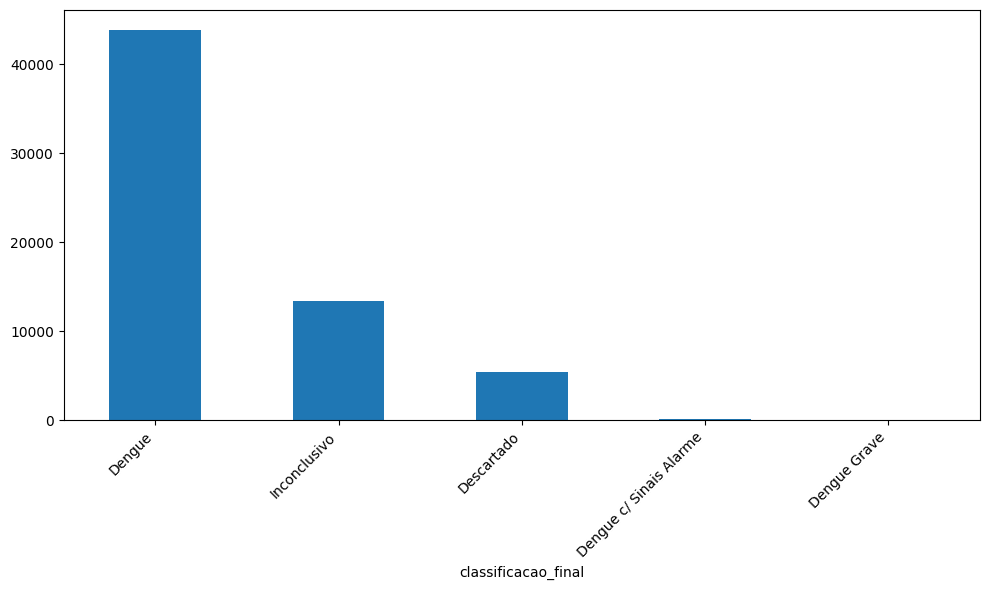

In [6]:
import matplotlib.pyplot as plt
df_deng_padrao['classificacao_final'].value_counts().plot(kind='bar', figsize=(10, 6))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusões iniciais quanto a classificação

- Para casos confirmados 68% sao dengue comum, 21% foi inconclusivo, 8% foi descartado
- Existem cerca de 69% de casos confirmados e 31% não confirmados
- Das mais de 62 mil entradas, cerca de 49 mil sao casos confirmados ou descartados, o restante não é possivel concluir se foi de fato dengue

### Analise do critérios de confirmação

In [7]:
df_deng_padrao['criterio_confirmacao'].value_counts()

criterio_confirmacao
2.0    37730
3.0     9390
1.0     4859
Name: count, dtype: int64

In [ ]:
with open('../src/dicionario-criterio.json', 'r') as f:
    dic_evol_dg = json.load(f)

df_deng_padrao['criterio_confirmacao'] = df_deng_padrao['criterio_confirmacao'].astype(str).map(dic_evol_dg)
df_deng_padrao['criterio_confirmacao']

0                           NaN
1                           NaN
2                           NaN
3                           NaN
4                           NaN
                  ...          
63287                       NaN
63288    Clínico Epidemiológico
63289           Em investigação
63290    Clínico Epidemiológico
63291    Clínico Epidemiológico
Name: criterio_confirmacao, Length: 63292, dtype: object

In [9]:
df_deng_padrao['criterio_confirmacao'].value_counts()

criterio_confirmacao
Clínico Epidemiológico    37730
Em investigação            9390
Laboratório                4859
Name: count, dtype: int64

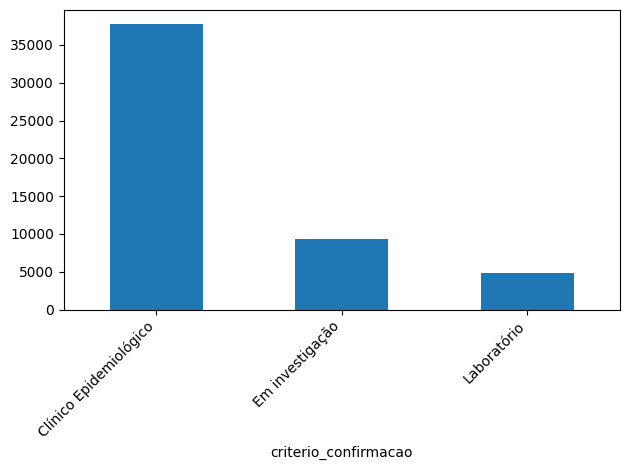

In [13]:
df_deng_padrao['criterio_confirmacao'].value_counts().plot(kind='bar')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
df_deng_padrao['criterio_confirmacao'].isnull().sum()

np.int64(11313)

### Critérios

- A maioria dos casos foi deita a confirmação por clinico epidemiologico comparado com o de laboratorio, possui alguns casos em investigação e alguns dados vazios

In [11]:
df_deng_padrao.to_csv('../data/final/df_deng_norm.csv', index=False)